<a href="https://colab.research.google.com/github/bukovskiy7777/Data-Analysis/blob/main/Fozzy_Group_Test_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Завантаження даних

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

In [2]:
# 1. Завантаження даних
stores_df = pd.read_csv('stores.csv')
pop_df = pd.read_csv('population.csv')
stores_df.head()

,Store,lat,long,Metric Store
0,Store 1,50.42,30.52,2.18
1,Store 2,50.50,30.51,2.64
2,Store 3,50.41,30.65,2.50
3,Store 4,50.47,30.48,2.38
4,Store 5,50.53,30.61,2.34


In [3]:
stores_df.shape

(92, 4)

## Завдання 1. Аналіз кореляцій

In [4]:
# 2. Налаштування параметрів для радіусу
EARTH_RADIUS = 6371000  # Радіус Землі в метрах
radius_corr = 200 # Радіус в метрах від кожного магазина для розрахунку середнього metric population

radius_corr_radians = radius_corr / EARTH_RADIUS
radius_corr_radians

3.1392246115209545e-05

In [5]:
# 3. Підготовка координат у радіанах (необхідно для метрики haversine)
pop_coords_rad = np.deg2rad(pop_df[['lat', 'lon']].values)
store_coords_rad = np.deg2rad(stores_df[['lat', 'long']].values)
pop_coords_rad

array([[0.88027426, 0.53451756],
       [0.8802603 , 0.53452628],
       [0.88028124, 0.53452454],
       ...,
       [0.88074026, 0.53210202],
       [0.88073328, 0.53211947],
       [0.88063729, 0.53270241]])

In [6]:
# Побудова дерева для пошуку точок у радіусі
tree = BallTree(pop_coords_rad, metric='haversine')

In [7]:
# 4. Пошук усіх точок населення в межах радіусу для кожного магазину
indices = tree.query_radius(store_coords_rad, r=radius_corr_radians)
indices

array([array([11262, 11396,  6605,  5695,  5694,  4915,  1658,  1657,  1656,
               1655, 10614,  1654])                                         ,
       array([ 400,  402,  403, 8447]),
       array([1155, 3326, 1156, 1154, 1157]),
       array([ 9415,  6354,  6356,  6142,  7945, 10338,  9413, 10337,  6128,
               7944, 11971,  6355,  7837,  6352,  7836])                    ,
       array([4307, 4059, 4056, 4060, 4072, 4057, 4306, 4305]),
       array([ 3330,  5078,  1416, 11081,  5043,  5041,  5042,  5076,  5045,
               5068,  5394,  5065,  5070,   225,  5392, 10249,  5067,  5393,
               9208,  5390,  5073,  5074,  5077,  5069, 10657,  4549, 10248,
               9207,  8594,  8593,  9205,  9206,  8592,  4544,  4545,  4543,
              10587,  5080,  5079,  4547, 12725])                           ,
       array([ 1792, 10098,  1502,  1791,  1789,  1501,  1508,  1505]),
       array([7995, 8012]), array([3513, 8923, 8927, 7939, 3523]),
       array([6

In [8]:
# 5. Розрахунок середньої метрики населення для кожного магазину
def get_mean_population(idx_list):
    if len(idx_list) == 0:
        return np.nan  # Якщо в радіусі N метрів немає жодної точки населення
    return pop_df.iloc[idx_list]['metric population'].mean()

In [9]:
stores_df['avg_pop_radius'] = [get_mean_population(idx) for idx in indices]
stores_df['count_pop_radius'] = [len(idx) for idx in indices]
stores_df.head()

,Store,lat,long,Metric Store,avg_pop_radius,count_pop_radius
0,Store 1,50.42,30.52,2.18,2.240833,12
1,Store 2,50.50,30.51,2.64,1.990000,4
2,Store 3,50.41,30.65,2.50,2.548000,5
3,Store 4,50.47,30.48,2.38,1.984667,15
4,Store 5,50.53,30.61,2.34,2.462500,8


In [10]:
# Видаляємо магазини, де не знайдено населення в радіусі (якщо такі є), для коректної кореляції
clean_df = stores_df.dropna(subset=['avg_pop_radius'])
clean_df.shape

(84, 6)

In [11]:
# Перегляд результатів
print(clean_df[['Store', 'Metric Store', 'avg_pop_radius', 'count_pop_radius']].head())

     Store  Metric Store  avg_pop_radius  count_pop_radius
0  Store 1          2.18        2.240833                12
1  Store 2          2.64        1.990000                 4
2  Store 3          2.50        2.548000                 5
3  Store 4          2.38        1.984667                15
4  Store 5          2.34        2.462500                 8


In [12]:
# 6. Аналіз кореляції (Завдання 1)
correlation = clean_df['Metric Store'].corr(clean_df['avg_pop_radius'])

correlation

np.float64(0.22256256715172057)

In [13]:
print(f"Кількість магазинів з метриками населення у радіусі {radius_corr}м: {len(clean_df)}")
print(f"Кореляція між характеристикою магазину та середнім характеристики населення: {correlation:.4f}")

Кількість магазинів з метриками населення у радіусі 200м: 84
Кореляція між характеристикою магазину та середнім характеристики населення: 0.2226


### Побудова регресійної моделі

Модель: Metric Store = 0.1321 * avg_pop_radius + 2.1450
R-squared: 0.0495


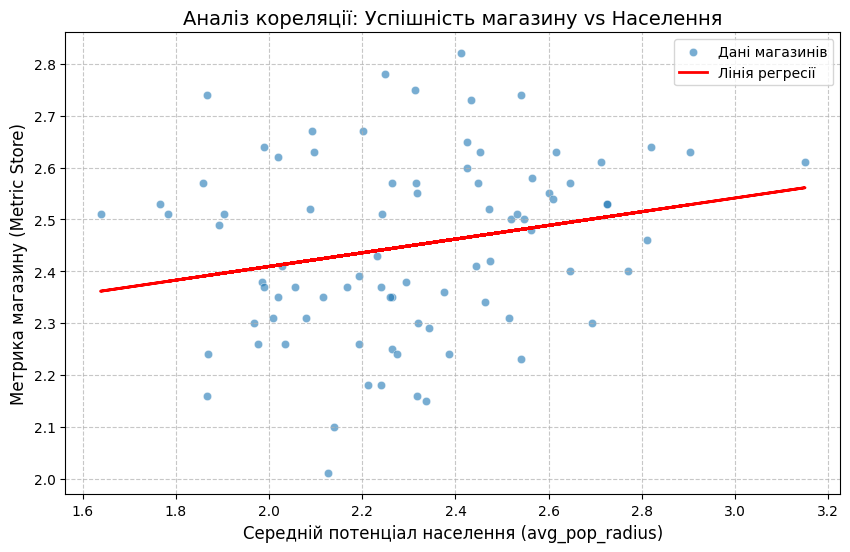

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Підготовка даних (clean_df)
X = clean_df[['avg_pop_radius']]
y = clean_df['Metric Store']

# Створення та навчання моделі
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

coef = model.coef_[0]
intercept = model.intercept_

r2 = model.score(X, y)
print(f"Модель: Metric Store = {coef:.4f} * avg_pop_radius + {intercept:.4f}")
print(f"R-squared: {r2:.4f}")

# Побудова графіка
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clean_df, x='avg_pop_radius', y='Metric Store', alpha=0.6, label='Дані магазинів')
plt.plot(clean_df['avg_pop_radius'], y_pred, color='red', linewidth=2, label='Лінія регресії')

plt.title('Аналіз кореляції: Успішність магазину vs Населення', fontsize=14)
plt.xlabel('Середній потенціал населення (avg_pop_radius)', fontsize=12)
plt.ylabel('Метрика магазину (Metric Store)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Залежність кореляції від радіусу района

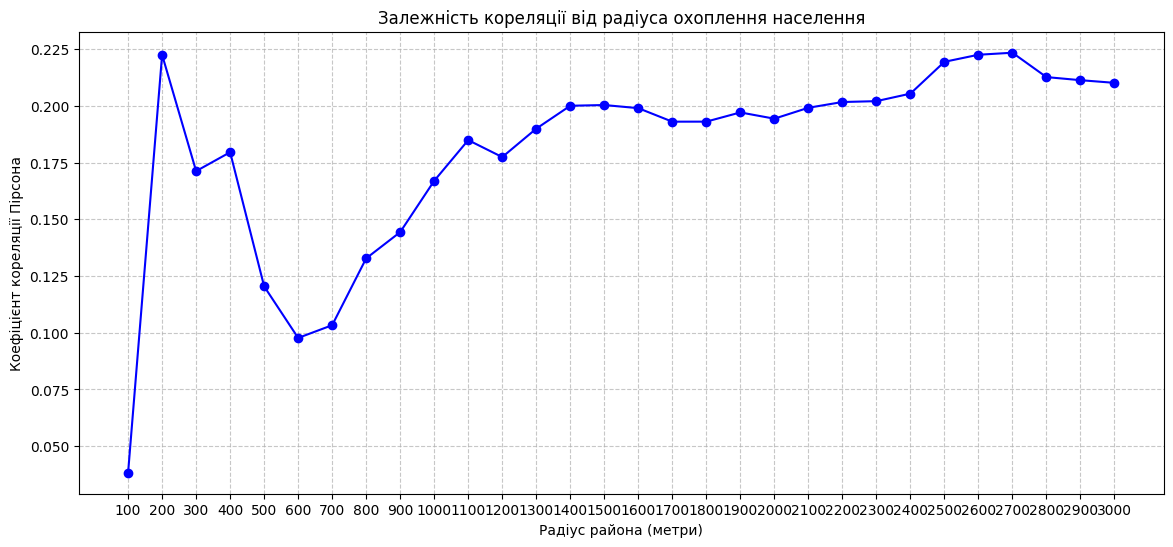

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

# 1. Підготовка даних
# Перетворення координат у радіани для BallTree (метрика haversine)
pop_coords_rad = np.deg2rad(pop_df[['lat', 'lon']].values)
store_coords_rad = np.deg2rad(stores_df[['lat', 'long']].values)

tree = BallTree(pop_coords_rad, metric='haversine')

# 2. Визначення діапазону радіусів для тестування (від 100м до 3000м з кроком 100м)
radii = np.arange(100, 3100, 100)
correlations = []

for r_meters in radii:
    # Перерахунок радіуса в радіани
    r_rad = r_meters / EARTH_RADIUS

    # Пошук індексів точок населення в радіусі
    indices = tree.query_radius(store_coords_rad, r=r_rad)

    # Розрахунок середнього населення для кожного магазину
    avg_pop = []
    for idx_list in indices:
        if len(idx_list) > 0:
            avg_pop.append(pop_df.iloc[idx_list]['metric population'].mean())
        else:
            avg_pop.append(np.nan)

    # Створення тимчасового DataFrame для розрахунку кореляції
    temp_df = pd.DataFrame({
        'store_metric': stores_df['Metric Store'],
        'pop_metric': avg_pop
    }).dropna()

    # Розрахунок кореляції Пірсона
    if len(temp_df) > 1:
        corr = temp_df['store_metric'].corr(temp_df['pop_metric'])
        correlations.append(corr)
    else:
        correlations.append(0)

# 3. Візуалізація результатів
plt.figure(figsize=(14, 6))
plt.plot(radii, correlations, marker='o', linestyle='-', color='b')
plt.title('Залежність кореляції від радіуса охоплення населення')
plt.xlabel('Радіус района (метри)')
plt.ylabel('Коефіцієнт кореляції Пірсона')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(radii)
plt.show()

# Завдання 2. Візуалізувати результати дослідження, побудувати геокарту розподілу характеристик

In [16]:
import folium
from folium.plugins import HeatMap

In [17]:
# 1. Ініціалізація карти (центруємо на середніх координатах магазинів)
map_center = [stores_df['lat'].mean(), stores_df['long'].mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles='CartoDB positron')

In [18]:
# 2. Додавання теплової карти (HeatMap) для населення
# Використовуємо координати та 'metric population' як інтенсивність
custom_gradient = {
    0.2: 'blue',
    0.4: 'lime',
    0.6: 'yellow',
    1: 'red'
}
heat_data = [[row['lat'], row['lon'], row['metric population']] for index, row in pop_df.iterrows()]
HeatMap(heat_data, name='Щільність населення', radius=15, blur=20, min_opacity=0.3, gradient=custom_gradient).add_to(m)


In [19]:
# Використовуємо 33-й та 66-й перцентилі для поділу на 3 групи (низька, середня, висока успішність)
low_threshold = stores_df['Metric Store'].quantile(0.33)
high_threshold = stores_df['Metric Store'].quantile(0.66)

print(f"Пороги за перцентилями: низький (33%) = {low_threshold:.2f}, високий (66%) = {high_threshold:.2f}")

# 2. функція вибору кольору
def get_store_color(metric):
    if metric >= high_threshold:
        return 'green'   # Топ-33% магазинів
    elif metric >= low_threshold:
        return 'orange'  # Середні 33%
    else:
        return 'red'     # Нижні 33%

# 3. Додавання магазинів на карту
# Колір та розмір маркера прив'язані до 'Metric Store'
fg_stores = folium.FeatureGroup(name='Існуючі магазини')
for index, row in stores_df.iterrows():
    metric_value = row['Metric Store']

    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=7, #metric_value * 5,
        popup=f"Магазин: {row['Store']}<br>Метрика: {row['Metric Store']}",
        color=get_store_color(metric_value),
        fill_color=get_store_color(metric_value),
        fill=True,
        fill_opacity=0.5
    ).add_to(fg_stores)
fg_stores.add_to(m)

Пороги за перцентилями: низький (33%) = 2.35, високий (66%) = 2.53


In [20]:
# 4. Додавання контролю шарів та збереження
folium.LayerControl().add_to(m)
m.save('store_population_analysis.html')

In [21]:
m

# Завдання 3. Запропонувати найкращі локації для відкриття нового store (за допомоги аналітичних досліджень або моделі)

In [22]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# 1. Підготовка даних
EARTH_RADIUS = 6371000  # метри
min_distance_from_store = 800  # Мінімальна відстань від існуючого магазину до пропонуємого, в метрах

radius_district_m = radius_corr # радіус району для кожної точки населенння. Для розрахунку середнього значення району, а не лише одного дому
min_points_count = 15 # мінімальна кількість домів для розрахунку середнього значення району, щоб район був "населений"
min_dist_between_new_stores = 800 # Мінімальна відстань між новими точками (метрів), щоб не дублювати магазини в сусідніх домах


## Варіант 1 - по найкращій локації населення одного будинку
цей варіант початковий. Варіант 2 має більшу перевагу

In [23]:
min_distance_from_store_rad = min_distance_from_store / EARTH_RADIUS

pop_coords_rad = np.deg2rad(pop_df[['lat', 'lon']].values)
store_coords_rad = np.deg2rad(stores_df[['lat', 'long']].values)

In [24]:
# 2. Побудова дерева для існуючих магазинів
store_tree = BallTree(store_coords_rad, metric='haversine')

In [25]:
# 3. Для кожної точки населення знаходимо відстань до найближчого магазину
distances, _ = store_tree.query(pop_coords_rad, k=1)
pop_df['dist_to_nearest_store_m'] = distances * EARTH_RADIUS
pop_df.head()

,lat,lon,metric population,dist_to_nearest_store_m
0,50.4360,30.6256,1.96,1218.764380
1,50.4352,30.6261,1.95,1141.766998
2,50.4364,30.6260,1.70,1220.538863
3,50.4362,30.6268,2.09,1161.635650
4,50.4354,30.6266,2.13,1123.103176


In [26]:
# 4. Додаємо у кожну точку (будинок) середнє значення метрики для района

# Побудова дерева для точок population
pop_tree = BallTree(pop_coords_rad, metric='haversine')

# Підготовка параметрів
radius_district_rad = radius_district_m / EARTH_RADIUS

# Знаходимо всі точки населення в радіусі radius_district_m для кожної точки населення. Це дозволить розрахувати "середній потенціал району"
indices_district = pop_tree.query_radius(pop_coords_rad, r=radius_district_rad)

# Додаємо новий стовпчик з середнім значенням метрики в радіусі району
pop_df['avg_pop_district'] = [pop_df.iloc[idx]['metric population'].mean() for idx in indices_district]

# Додаємо кількість точок у радіусі
pop_df['count_pop_district'] = [len(idx) for idx in indices_district]

pop_df.head()

,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district
0,50.4360,30.6256,1.96,1218.764380,1.890000,15
1,50.4352,30.6261,1.95,1141.766998,1.898571,14
2,50.4364,30.6260,1.70,1220.538863,1.917647,17
3,50.4362,30.6268,2.09,1161.635650,1.958571,14
4,50.4354,30.6266,2.13,1123.103176,1.876429,14


In [27]:
# 5. Фільтрація: обираємо зони, де магазинів немає поруч (відстань > min_distance_from_store) та кількість будинків >= min_points_count
# Та сортуємо їх за показником населення будинку
candidate_locations = pop_df[(pop_df['dist_to_nearest_store_m'] > min_distance_from_store) & (pop_df['count_pop_district'] >= min_points_count)] #
# new_locations_v1 = candidate_locations.sort_values(by='metric population', ascending=False).head(15)

In [28]:

# Алгоритм відбору унікальних точок
new_locations_v1 = []

while len(new_locations_v1) < 15 and len(candidate_locations) > 0:
    # Беремо найкращу точку (верхню у відсортованому списку)
    best_candidate = candidate_locations.iloc[0]
    new_locations_v1.append(best_candidate.to_dict())

    # Розраховуємо відстань від цієї точки до всіх інших у списку кандидатів
    best_coords_rad = np.deg2rad([[best_candidate['lat'], best_candidate['lon']]])
    cand_coords_rad = np.deg2rad(candidate_locations[['lat', 'lon']].values)

    # Використовуємо BallTree для швидкого пошуку або формулу haversine
    temp_tree = BallTree(cand_coords_rad, metric='haversine')
    # Знаходимо всі індекси точок у радіусі min_dist_between_new_stores від щойно обраної
    indices_to_remove = temp_tree.query_radius(best_coords_rad, r=min_dist_between_new_stores/EARTH_RADIUS)

    # Видаляємо ці точки (включаючи саму обрану), щоб наступна точка була в іншому районі
    candidate_locations = candidate_locations.drop(candidate_locations.index[indices_to_remove[0]])

# Перетворюємо результат у DataFrame
new_locations_v1 = pd.DataFrame(new_locations_v1)

# Додаємо форекаст метрики Store Metric по регресійній моделі з завдання 1
new_locations_v1["store_metric_forecast"] = coef * new_locations_v1["avg_pop_district"] + intercept

print("Топ-15 унікальних локацій у різних районах:")
new_locations_v1.head(15)


Топ-15 унікальних локацій у різних районах:


,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district,store_metric_forecast
0,50.4360,30.6256,1.96,1218.764380,1.890000,15.0,2.394672
1,50.4411,30.6144,1.97,1420.949339,1.991429,21.0,2.408069
2,50.4369,30.5373,1.92,925.203719,2.068667,15.0,2.418270
3,50.4506,30.6137,2.16,972.293760,2.006667,15.0,2.410082
4,50.4373,30.5012,1.35,848.107078,1.988333,18.0,2.407660
5,50.4411,30.5489,2.11,1820.781095,1.937727,22.0,2.400976
6,50.4745,30.4449,1.93,1179.977975,1.895455,22.0,2.395393
7,50.4187,30.5479,2.41,978.772707,2.098667,15.0,2.422233
8,50.4481,30.5146,1.67,978.489842,1.879643,28.0,2.393304
9,50.4511,30.5250,1.91,1051.035769,1.951724,29.0,2.402825


In [29]:
#print("Топ-15 рекомендованих локацій для нових магазинів:")
#new_locations_v1[['lat', 'lon', 'metric population', 'dist_to_nearest_store_m', 'avg_pop_district', 'count_pop_district']].head(15)

In [30]:
# Перегляд всіх кандидатів для інформації
candidate_locations.sort_values(by='metric population', ascending=False)

,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district
10396,50.4423,30.4374,3.12,875.770730,2.392353,17
11263,50.4326,30.5148,3.07,901.500678,1.758889,27
9538,50.4717,30.5995,3.03,923.595880,2.103333,15
4207,50.3944,30.6490,3.03,891.468145,2.572667,15
9977,50.4336,30.5131,2.99,863.279156,1.812222,27
...,...,...,...,...,...,...
12067,50.4695,30.4224,0.07,879.356451,0.539565,23
10964,50.4695,30.4229,0.00,914.675369,0.516250,24
10927,50.4698,30.4230,0.00,920.327302,0.516250,24
10930,50.4699,30.4227,-0.01,898.894276,0.516250,24


## Візуалізація аналізу

In [31]:
import folium
from folium.plugins import HeatMap

# 1. Ініціалізація мапи (центруємо по магазинам)
map_center = [stores_df['lat'].mean(), stores_df['long'].mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles='CartoDB positron')

# 2. Шар теплової карти населення
custom_gradient = {
    0.2: 'blue',
    0.4: 'lime',
    0.6: 'yellow',
    1: 'red'
}
heat_data = [[row['lat'], row['lon'], row['metric population']] for index, row in pop_df.iterrows()]
HeatMap(heat_data, name='Щільність населення', radius=15, blur=20, min_opacity=0.3, gradient=custom_gradient).add_to(m)

# 3. Додавання існуючих магазинів
fg_stores = folium.FeatureGroup(name='Існуючі магазини')
for index, row in stores_df.iterrows():
    metric_value = row['Metric Store']

    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=7,
        popup=f"Store ID: {row['Store']}<br>Metric: {row['Metric Store']}",
        color=get_store_color(metric_value),
        fill_color=get_store_color(metric_value),
        fill=True,
        fill_opacity=0.5
    ).add_to(fg_stores)
fg_stores.add_to(m)

# 4. Додавання рекомендованих локацій (зелені маркери)
# Використання new_locations_v1 з попереднього крока
fg_new = folium.FeatureGroup(name='Рекомендовані локації')
for index, row in new_locations_v1.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Рекомендація №{index+1}<br>Метрика населення: {row['metric population']:.2f}<br>Метрика району: {row['avg_pop_district']:.2f}"
            +f"<br>Відстань до найближчого магазина: {row['dist_to_nearest_store_m']:.0f}<br>Кількість домів у радіусі:{row['count_pop_district']:.0f}"
            +f"<br>Store Metric forecast: {row['store_metric_forecast']:.2f}",
        icon=folium.Icon(color='green')
    ).add_to(fg_new)
fg_new.add_to(m)

# 5. Керування шарами
folium.LayerControl().add_to(m)

# Збереження
m.save('new_locations_v1.html')
m

## Варіант 2 - по найкращій локації населення району
для кожного будинку (точки) рахується середня метрика будинків в радіусі radius_district_m

In [32]:
# Перегляд датафрейму для інформації
pop_df.head()

,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district
0,50.4360,30.6256,1.96,1218.764380,1.890000,15
1,50.4352,30.6261,1.95,1141.766998,1.898571,14
2,50.4364,30.6260,1.70,1220.538863,1.917647,17
3,50.4362,30.6268,2.09,1161.635650,1.958571,14
4,50.4354,30.6266,2.13,1123.103176,1.876429,14


In [33]:
# Середньі метрики по району avg_pop_district і count_pop_district

pop_df

,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district
0,50.4360,30.6256,1.96,1218.764380,1.890000,15
1,50.4352,30.6261,1.95,1141.766998,1.898571,14
2,50.4364,30.6260,1.70,1220.538863,1.917647,17
3,50.4362,30.6268,2.09,1161.635650,1.958571,14
4,50.4354,30.6266,2.13,1123.103176,1.876429,14
...,...,...,...,...,...,...
12747,50.4751,30.4478,1.97,1032.976324,1.973333,15
12748,50.4623,30.4874,2.37,315.087373,2.193333,12
12749,50.4627,30.4872,2.56,359.749888,2.193333,12
12750,50.4623,30.4882,2.52,285.730856,2.193333,12


In [34]:
pop_df.to_csv('pop_df.csv', index=True)

In [35]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# 4. Обираємо лише ті точки, що далеко від існуючих магазинів (> min_distance_from_store) та кількість будинків >= min_points_count
candidates = pop_df[(pop_df['dist_to_nearest_store_m'] > min_distance_from_store)
                    & (pop_df['count_pop_district'] >= min_points_count)].sort_values(by='avg_pop_district', ascending=False).copy()
candidates.shape

(2286, 6)

In [36]:
candidates.head(10)

,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district
11068,50.3903,30.6276,2.55,1091.925238,2.775625,16
11066,50.3904,30.6265,2.96,1095.923441,2.772353,17
11065,50.3905,30.6291,2.71,1058.276511,2.684375,16
10625,50.4687,30.6031,2.92,1083.690685,2.651333,15
11073,50.3914,30.6297,2.56,956.512787,2.629375,16
4216,50.3932,30.6476,2.63,928.406352,2.604667,15
4207,50.3944,30.6490,3.03,891.468145,2.572667,15
11185,50.4696,30.6030,2.66,1175.752910,2.569333,15
9528,50.4680,30.6024,2.64,1039.568887,2.481333,15
6773,50.4414,30.4361,2.76,995.353298,2.476000,15


In [37]:
# 5. Алгоритм відбору унікальних точок
new_locations_v2 = []

In [38]:
while len(new_locations_v2) < 15 and len(candidates) > 0:
    # Беремо найкращу точку (верхню у відсортованому списку)
    best_candidate = candidates.iloc[0]
    new_locations_v2.append(best_candidate.to_dict())

    # Розраховуємо відстань від цієї точки до всіх інших у списку кандидатів
    best_coords_rad = np.deg2rad([[best_candidate['lat'], best_candidate['lon']]])
    cand_coords_rad = np.deg2rad(candidates[['lat', 'lon']].values)

    # Використовуємо BallTree для швидкого пошуку або формулу haversine
    temp_tree = BallTree(cand_coords_rad, metric='haversine')
    # Знаходимо всі індекси точок у радіусі min_dist_between_new_stores від щойно обраної
    indices_to_remove = temp_tree.query_radius(best_coords_rad, r=min_dist_between_new_stores/EARTH_RADIUS)

    # Видаляємо ці точки (включаючи саму обрану), щоб наступна точка була в іншому районі
    candidates = candidates.drop(candidates.index[indices_to_remove[0]])

# Перетворюємо результат у DataFrame
new_locations_v2 = pd.DataFrame(new_locations_v2)

print("Топ-15 унікальних локацій у різних районах:")
#print(new_locations_v2[['lat', 'lon', 'avg_pop_district']])

# Додаємо форекаст метрики Store Metric по регресійній моделі з завдання 1
new_locations_v2["store_metric_forecast"] = coef * new_locations_v2["avg_pop_district"] + intercept
new_locations_v2.head(15)

Топ-15 унікальних локацій у різних районах:


,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district,store_metric_forecast
0,50.3903,30.6276,2.55,1091.925238,2.775625,16.0,2.511644
1,50.4687,30.6031,2.92,1083.690685,2.651333,15.0,2.495228
2,50.3932,30.6476,2.63,928.406352,2.604667,15.0,2.489064
3,50.4414,30.4361,2.76,995.353298,2.476000,15.0,2.472070
4,50.4350,30.4767,2.74,1093.778039,2.458667,15.0,2.469781
5,50.3855,30.4708,2.42,980.007881,2.423125,16.0,2.465086
6,50.4020,30.5314,2.42,1590.247594,2.420667,15.0,2.464762
7,50.3986,30.3807,1.94,1864.890767,2.396667,18.0,2.461592
8,50.4794,30.3425,2.16,1060.099046,2.384667,15.0,2.460007
9,50.4365,30.6343,2.58,827.879436,2.353125,16.0,2.455841


In [39]:
new_locations_v2.shape

(15, 7)

## Візуалізація аналізу

In [40]:
import folium
from folium.plugins import HeatMap

# 1. Ініціалізація мапи (центруємо по магазинах)
map_center = [stores_df['lat'].mean(), stores_df['long'].mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles='CartoDB positron')

# 2. Шар теплової карти населення
custom_gradient = {
    0.2: 'blue',
    0.4: 'lime',
    0.6: 'yellow',
    1: 'red'
}
heat_data = [[row['lat'], row['lon'], row['metric population']] for index, row in pop_df.iterrows()]
HeatMap(heat_data, name='Щільність населення', radius=15, blur=20, min_opacity=0.3, gradient=custom_gradient).add_to(m)

# 3. Додавання існуючих магазинів
fg_stores = folium.FeatureGroup(name='Існуючі магазини')
for index, row in stores_df.iterrows():
    metric_value = row['Metric Store']

    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=7,
        popup=f"Store ID: {row['Store']}<br>Metric: {row['Metric Store']}",
        color=get_store_color(metric_value),
        fill_color=get_store_color(metric_value),
        fill=True,
        fill_opacity=0.7
    ).add_to(fg_stores)
fg_stores.add_to(m)

# 4. Додавання рекомендованих локацій (зелені маркери)
# Використання new_locations_v2 з попереднього крока
fg_new = folium.FeatureGroup(name='Рекомендовані локації')
for index, row in new_locations_v2.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Рекомендація №{index+1}<br>Метрика населення: {row['metric population']:.2f}<br>Метрика району: {row['avg_pop_district']:.2f}"
            +f"<br>Відстань до найближчого магазина: {row['dist_to_nearest_store_m']:.0f}<br>Кількість домів у радіусі:{row['count_pop_district']:.0f}"
            +f"<br>Store Metric forecast: {row['store_metric_forecast']:.2f}",
        icon=folium.Icon(color='green')
    ).add_to(fg_new)
fg_new.add_to(m)

# 5. Керування шарами
folium.LayerControl().add_to(m)

# Збереження
m.save('new_locations_v2.html')
m

# Дані з OpenStreetMap

In [41]:
!pip install osmnx

## Транспортні зупинки

In [46]:
import osmnx as ox

# 1. Визначаємо центр пошуку на основі середніх координат магазинів
center_lat = stores_df['lat'].mean()
center_lon = stores_df['long'].mean()
center_point = (center_lat, center_lon)

city_radius = 15000

# 2. Отримуємо дані про зупинки транспорту (public_transport) з OSM. Це дозволить доповнити вибірку характеристиками доступності транспорту
transport_points = ox.features_from_point(center_point, tags={'highway': 'bus_stop', 'railway': 'subway_entrance'}, dist=city_radius)

# 3. Вибираємо координати знайдених об'єктів
# Додаємо колонки 'highway', 'railway' та 'public_transport' у вибірку (якщо вони є в результатах)
available_cols = [col for col in ['geometry', 'highway', 'railway', 'public_transport'] if col in transport_points.columns]
transport_data = transport_points[available_cols].copy()

centroids = transport_data.geometry.centroid
transport_data['lat'] = centroids.geometry.y
transport_data['lon'] = centroids.geometry.x

# Якщо заповнений тег 'highway', беремо його, інакше — 'railway' та 'public_transport'
type_columns = [col for col in ['highway', 'railway', 'public_transport'] if col in transport_data.columns]
if type_columns:
    # Метод bfill об'єднує колонки по порядку зліва направо
    # iloc[:, 0] бере ітоговий результат
    transport_data['type'] = transport_data[type_columns].bfill(axis=1).iloc[:, 0]
else:
    transport_data['type'] = 'unknown_transport'

print(f"Знайдено точок трафіку: {len(transport_data)}")

print("\nКількість об'єктів за типами:")
print(transport_data['type'].value_counts())

Знайдено точок трафіку: 3335

Кількість об'єктів за типами:
type
bus_stop           3065
subway_entrance     259
elevator             11
Name: count, dtype: int64


/tmp/ipykernel_50052/2233359165.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = transport_data.geometry.centroid


In [47]:
transport_data.head()

geometry   highway          railway  \
element id                                                                
node    254277339  POINT (30.55167 50.35091)  bus_stop              NaN   
        255368753  POINT (30.50593 50.44433)       NaN  subway_entrance   
        256370846  POINT (30.61343 50.45651)       NaN  subway_entrance   
        256558221  POINT (30.60421 50.39452)       NaN  subway_entrance   
        258566056  POINT (30.65805 50.42152)  bus_stop              NaN   

                  public_transport        lat        lon             type  
element id                                                                 
node    254277339    stop_position  50.350908  30.551665         bus_stop  
        255368753              NaN  50.444333  30.505928  subway_entrance  
        256370846              NaN  50.456508  30.613428  subway_entrance  
        256558221              NaN  50.394519  30.604210  subway_entrance  
        258566056         platform  50.421517  30.658049         bus_stop

In [48]:
transport_data.to_csv("transport_data.csv", index=True)

## Магазини всі

In [49]:
import osmnx as ox

# Визначаємо центр на основі середніх координат магазинів
center_lat = stores_df['lat'].mean()
center_lon = stores_df['long'].mean()
center_point = (center_lat, center_lon)

# Визначаємо теги для пошуку (наприклад, супермаркети)
tags = {'shop': 'supermarket'}

# Завантажуємо дані в радіусі city_radius метрів
supermarkets = ox.features_from_point(center_point, tags=tags, dist=city_radius)
centroids = supermarkets.geometry.centroid

# Вибираємо координати для подальшого аналізу
supermarkets['lat'] = centroids.geometry.y
supermarkets['lon'] = centroids.geometry.x

print(f"Знайдено об'єктів: {len(supermarkets)}")
print(supermarkets[['name', 'lat', 'lon']].head())

Знайдено об'єктів: 925
                            name        lat        lon
element id                                            
node    256193823  Велика Кишеня  50.432824  30.541425
        256224809           Фора  50.448963  30.619014
        256488787  Thrash! Траш!  50.519074  30.501832
        294623182            EKO  50.587276  30.494606
        294624122          Varus  50.586632  30.494630


/tmp/ipykernel_50052/4003468261.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = supermarkets.geometry.centroid


In [50]:
print("\nКількість магазинів за назвою:")
supermarkets['name'].value_counts().head(15)


Кількість магазинів за назвою:


,count
name,
Фора,215
АТБ-Маркет,139
Сільпо,104
Novus,68
ЛотОК,66
АТБ-маркет,46
Thrash! Траш!,28
ЕКО маркет,23
Varus,20


In [51]:
supermarkets.to_csv("supermarkets.csv", index=True)

In [52]:
supermarkets.head()

geometry           name        name:uk  \
element id                                                                   
node    256193823  POINT (30.54143 50.43282)  Велика Кишеня  Велика Кишеня   
        256224809  POINT (30.61901 50.44896)           Фора           Фора   
        256488787  POINT (30.50183 50.51907)  Thrash! Траш!          Траш!   
        294623182  POINT (30.49461 50.58728)            EKO            EKO   
        294624122  POINT (30.49463 50.58663)          Varus          Varus   

                          shop wheelchair          brand brand:en brand:uk  \
element id                                                                   
node    256193823  supermarket        yes            NaN      NaN      NaN   
        256224809  supermarket        NaN           Фора     Fora     Фора   
        256488787  supermarket        NaN  Thrash! Траш!  Thrash!    Траш!   
        294623182  supermarket        NaN            NaN      NaN      NaN   
        294624122  supermarket        NaN            NaN      NaN      NaN   

                  brand:wikidata             brand:wikipedia  ...  \
element id                                                    ...   
node    256193823            NaN                         NaN  ...   
        256224809       Q4491805  uk:Фора (мережа магазинів)  ...   
        256488787      Q56364758                         NaN  ...   
        294623182            NaN                         NaN  ...   
        294624122            NaN                         NaN  ...   

                  internet_access:access toilets:access roof:material indoor  \
element id                                                                     
node    256193823                    NaN            NaN           NaN    NaN   
        256224809                    NaN            NaN           NaN    NaN   
        256488787                    NaN            NaN           NaN    NaN   
        294623182                    NaN            NaN           NaN    NaN   
        294624122                    NaN            NaN           NaN    NaN   

                  indoor:level name:fr level:ref type        lat        lon  
element id                                                                   
node    256193823          NaN     NaN       NaN  NaN  50.432824  30.541425  
        256224809          NaN     NaN       NaN  NaN  50.448963  30.619014  
        256488787          NaN     NaN       NaN  NaN  50.519074  30.501832  
        294623182          NaN     NaN       NaN  NaN  50.587276  30.494606  
        294624122          NaN     NaN       NaN  NaN  50.586632  30.494630  

[5 rows x 132 columns]

In [53]:
# Список брендів мережі
own_brands_list = ['фора', 'сільпо', 'silpo', 'thrash', 'траш']

# Функція для визначення типу магазину
def classify_store(name):
    if pd.isna(name):
        return 'Competitor'

    name_lower = str(name).lower()
    # Перевіряємо, чи є хоча б один з брендів у назві
    if any(brand in name_lower for brand in own_brands_list):
        return 'Own Store'
    return 'Competitor'

# Додаємо колонку з типом у ваш основний датасет supermarkets
supermarkets['store_type'] = supermarkets['name'].apply(classify_store)
supermarkets[['name', 'lat', 'lon', 'store_type']].head()

name        lat        lon  store_type
element id                                                        
node    256193823  Велика Кишеня  50.432824  30.541425  Competitor
        256224809           Фора  50.448963  30.619014   Own Store
        256488787  Thrash! Траш!  50.519074  30.501832   Own Store
        294623182            EKO  50.587276  30.494606  Competitor
        294624122          Varus  50.586632  30.494630  Competitor

## Competitors

In [54]:
# Датасет конкурентів
competitors = supermarkets[supermarkets['store_type'] == 'Competitor'].copy()

# Cвої магазини, знайдені в OSM
own_osm_stores = supermarkets[supermarkets['store_type'] == 'Own Store'].copy()

print(f"Загалом знайдено об'єктів: {len(supermarkets)}")
print(f"З них конкурентів: {len(competitors)}")
print(f"З них свої магазини (OSM): {len(own_osm_stores)}")

# Перші кілька рядків конкурентів
print(competitors[['name', 'lat', 'lon']].head(15))

Загалом знайдено об'єктів: 925
З них конкурентів: 576
З них свої магазини (OSM): 349
                            name        lat        lon
element id                                            
node    256193823  Велика Кишеня  50.432824  30.541425
        294623182            EKO  50.587276  30.494606
        294624122          Varus  50.586632  30.494630
        294632826     ЕКО маркет  50.512229  30.412261
        308676131     ЕКО маркет  50.401672  30.636394
        309471560     ВК Експрес  50.418805  30.547497
        358324299     Еко-Маркет  50.404104  30.523644
        423262670     АТБ-Маркет  50.510603  30.617195
        429461910     АТБ-Маркет  50.500803  30.585726
        436763482     АТБ-маркет  50.408725  30.403796
        442539022     АТБ-Маркет  50.416606  30.644291
        457511132     АТБ-Маркет  50.493445  30.406609
        457951854  Велика Кишеня  50.406565  30.628254
        504234958     ЕКО маркет  50.502525  30.591845
        538205745     ЕКО маркет  5

## Додавання конкурентів

In [55]:
clean_df.head()

,Store,lat,long,Metric Store,avg_pop_radius,count_pop_radius
0,Store 1,50.42,30.52,2.18,2.240833,12
1,Store 2,50.50,30.51,2.64,1.990000,4
2,Store 3,50.41,30.65,2.50,2.548000,5
3,Store 4,50.47,30.48,2.38,1.984667,15
4,Store 5,50.53,30.61,2.34,2.462500,8


In [57]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# 1. Підготовка координат конкурентів (отриманих з OSM на попередньому кроці)
# Використовуємо радіани для роботи з метрикою haversine
comp_coords_rad = np.deg2rad(competitors[['lat', 'lon']].values)
comp_tree = BallTree(comp_coords_rad, metric='haversine')

rad_200 = 200 / EARTH_RADIUS
rad_500 = 500 / EARTH_RADIUS

# 2. Функція для підрахунку об'єктів у радіусі
def count_neighbors(df, lat_col, lon_col, tree, radius):
    coords_rad = np.deg2rad(df[[lat_col, lon_col]].values)
    # Повертає масив списків індексів точок, що потрапили в радіус
    indices = tree.query_radius(coords_rad, r=radius)
    return [len(idx_list) for idx_list in indices]

# 3. Оновлення датасета існуючих магазинів
clean_df.loc[:, 'comp_200m'] = count_neighbors(clean_df, 'lat', 'long', comp_tree, rad_200)
clean_df.loc[:, 'comp_500m'] = count_neighbors(clean_df, 'lat', 'long', comp_tree, rad_500)

# 4. Оновлення датасета пропозицій (new_locations_v2)
new_locations_v2['comp_200m'] = count_neighbors(new_locations_v2, 'lat', 'lon', comp_tree, rad_200)
new_locations_v2['comp_500m'] = count_neighbors(new_locations_v2, 'lat', 'lon', comp_tree, rad_500)

# Виведення результатів
print("Приклад даних для магазинів:")
clean_df[['Store', 'avg_pop_radius', 'count_pop_radius', 'Metric Store', 'comp_200m', 'comp_500m']].head(10)

Приклад даних для магазинів:


,Store,avg_pop_radius,count_pop_radius,Metric Store,comp_200m,comp_500m
0,Store 1,2.240833,12,2.18,1,2
1,Store 2,1.990000,4,2.64,0,1
2,Store 3,2.548000,5,2.50,0,5
3,Store 4,1.984667,15,2.38,0,2
4,Store 5,2.462500,8,2.34,0,1
5,Store 6,1.867073,41,2.16,0,2
6,Store 7,2.445000,8,2.41,0,3
7,Store 8,2.055000,2,2.37,0,1
8,Store 9,2.248000,5,2.78,0,1
9,Store 10,2.096667,3,2.63,1,5


In [58]:
print("\nПриклад даних для нових пропозицій:")
new_locations_v2[['avg_pop_district', 'count_pop_district', 'store_metric_forecast', 'comp_200m', 'comp_500m']].head(10)


Приклад даних для нових пропозицій:


,avg_pop_district,count_pop_district,store_metric_forecast,comp_200m,comp_500m
0,2.775625,16.0,2.511644,2,3
1,2.651333,15.0,2.495228,2,3
2,2.604667,15.0,2.489064,0,2
3,2.476000,15.0,2.472070,0,4
4,2.458667,15.0,2.469781,1,4
5,2.423125,16.0,2.465086,2,6
6,2.420667,15.0,2.464762,1,3
7,2.396667,18.0,2.461592,2,8
8,2.384667,15.0,2.460007,1,1
9,2.353125,16.0,2.455841,0,0


## Додавання зупинок

In [60]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# 1. Підготовка координат зупинок (отриманих з OSM на попередньому кроці)
# Використовуємо радіани для роботи з метрикою haversine
bus_coords_rad = np.deg2rad(transport_data[transport_data['type']=='bus_stop'][['lat', 'lon']].values)
bus_tree = BallTree(bus_coords_rad, metric='haversine')

subway_coords_rad = np.deg2rad(transport_data[transport_data['type']=='subway_entrance'][['lat', 'lon']].values)
subway_tree = BallTree(subway_coords_rad, metric='haversine')

bus_rad = 150 / EARTH_RADIUS
subway_rad = 150 / EARTH_RADIUS

# 2. Функція для підрахунку об'єктів у радіусі
def count_neighbors(df, lat_col, lon_col, tree, radius):
    coords_rad = np.deg2rad(df[[lat_col, lon_col]].values)
    # Повертає масив списків індексів точок, що потрапили в радіус
    indices = tree.query_radius(coords_rad, r=radius)
    return [len(idx_list) for idx_list in indices]

# 3. Оновлення датасета існуючих магазинів
clean_df.loc[:, 'bus_rad'] = count_neighbors(clean_df, 'lat', 'long', bus_tree, bus_rad)
clean_df.loc[:, 'subway_rad'] = count_neighbors(clean_df, 'lat', 'long', subway_tree, subway_rad)

# 4. Оновлення датасета пропозицій (new_locations_v2)
new_locations_v2['bus_rad'] = count_neighbors(new_locations_v2, 'lat', 'lon', bus_tree, bus_rad)
new_locations_v2['subway_rad'] = count_neighbors(new_locations_v2, 'lat', 'lon', subway_tree, subway_rad)

# Виведення результатів
print("Приклад даних для магазинів:")
clean_df[['Store', 'avg_pop_radius', 'count_pop_radius', 'Metric Store', 'comp_200m', 'comp_500m', 'bus_rad', 'subway_rad']].head(10)

Приклад даних для магазинів:


,Store,avg_pop_radius,count_pop_radius,Metric Store,comp_200m,comp_500m,bus_rad,subway_rad
0,Store 1,2.240833,12,2.18,1,2,2,4
1,Store 2,1.990000,4,2.64,0,1,0,0
2,Store 3,2.548000,5,2.50,0,5,0,0
3,Store 4,1.984667,15,2.38,0,2,0,0
4,Store 5,2.462500,8,2.34,0,1,2,0
5,Store 6,1.867073,41,2.16,0,2,3,0
6,Store 7,2.445000,8,2.41,0,3,1,0
7,Store 8,2.055000,2,2.37,0,1,0,0
8,Store 9,2.248000,5,2.78,0,1,0,0
9,Store 10,2.096667,3,2.63,1,5,0,0


In [61]:
print("\nПриклад даних для нових пропозицій:")
new_locations_v2[['avg_pop_district', 'count_pop_district', 'store_metric_forecast', 'comp_200m', 'comp_500m', 'bus_rad', 'subway_rad']].head(10)


Приклад даних для нових пропозицій:


,avg_pop_district,count_pop_district,store_metric_forecast,comp_200m,comp_500m,bus_rad,subway_rad
0,2.775625,16.0,2.511644,2,3,1,0
1,2.651333,15.0,2.495228,2,3,0,0
2,2.604667,15.0,2.489064,0,2,0,0
3,2.476000,15.0,2.472070,0,4,1,0
4,2.458667,15.0,2.469781,1,4,0,0
5,2.423125,16.0,2.465086,2,6,0,0
6,2.420667,15.0,2.464762,1,3,0,0
7,2.396667,18.0,2.461592,2,8,0,0
8,2.384667,15.0,2.460007,1,1,1,0
9,2.353125,16.0,2.455841,0,0,0,0


## Матриця кореляцій

Матриця кореляції:
                  Metric Store  avg_pop_radius  count_pop_radius  comp_200m  \
Metric Store          1.000000        0.222563         -0.050052  -0.147576   
avg_pop_radius        0.222563        1.000000         -0.508048   0.160033   
count_pop_radius     -0.050052       -0.508048          1.000000   0.009963   
comp_200m            -0.147576        0.160033          0.009963   1.000000   
comp_500m            -0.009697        0.286407          0.061796   0.530388   
bus_rad              -0.219925       -0.030922          0.172271   0.258946   
subway_rad           -0.157301       -0.032179          0.051095   0.192133   

                  comp_500m   bus_rad  subway_rad  
Metric Store      -0.009697 -0.219925   -0.157301  
avg_pop_radius     0.286407 -0.030922   -0.032179  
count_pop_radius   0.061796  0.172271    0.051095  
comp_200m          0.530388  0.258946    0.192133  
comp_500m          1.000000  0.129562    0.008416  
bus_rad            0.129562  1.00000

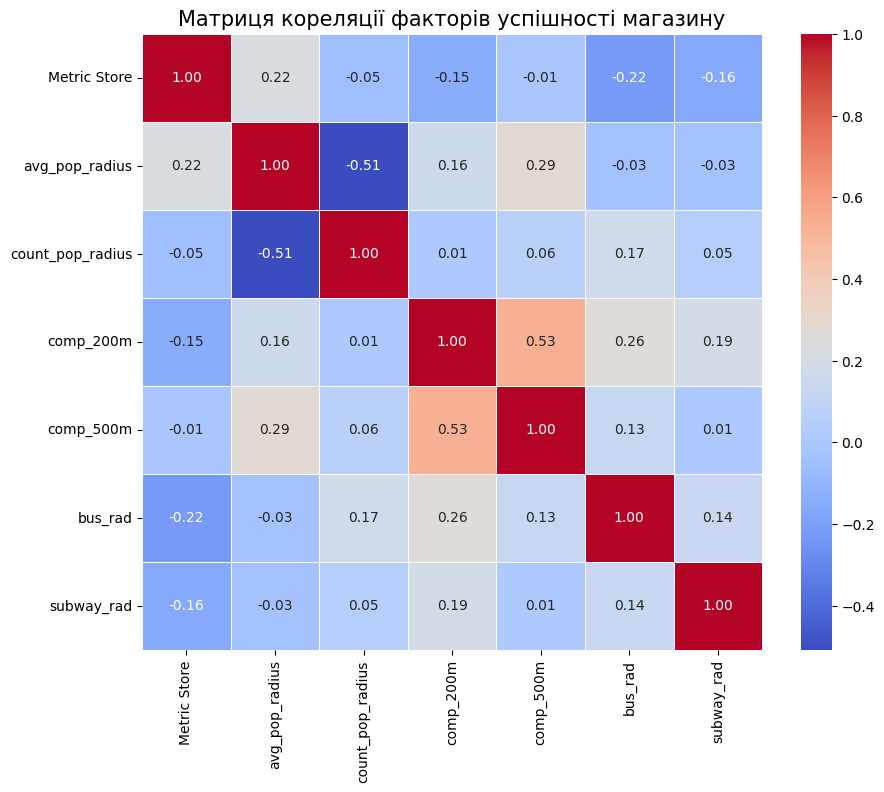

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Вибираємо лише чисельні колонки для аналізу кореляції
corr_columns = ['Metric Store', 'avg_pop_radius', 'count_pop_radius', 'comp_200m', 'comp_500m', 'bus_rad', 'subway_rad']
correlation_matrix = clean_df[corr_columns].corr()

# Виведення матриці у консоль
print("Матриця кореляції:")
print(correlation_matrix)

# Візуалізація за допомогою теплової карти (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Матриця кореляції факторів успішності магазину', fontsize=15)
plt.show()

## Побудова моделі

In [64]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

df = clean_df

# З матриці кореляцій обираємо features
features = ['avg_pop_radius', 'comp_200m', 'bus_rad', 'subway_rad']
target = 'Metric Store'

X = df[features].values
y = df[target].values

# Даних 84 рядка, використовуємо LeaveOneOut крос-валідацію
loo = LeaveOneOut()

# Масштабування features (для Ridge)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Розрахунок best_alpha
param_grid = {'alpha': np.logspace(-3, 3, 100)}
grid_search = GridSearchCV(Ridge(), param_grid, cv=loo, scoring='neg_mean_absolute_error')
grid_search.fit(X_scaled, y)

best_alpha = grid_search.best_params_['alpha']


# Навчання моделі з кращим alpha
final_model = Ridge(alpha=best_alpha)
final_model.fit(X_scaled, y)

# Розрахунок метрик якості на крос-валідаціЇ
y_pred_cv = []
for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model_cv = Ridge(alpha=best_alpha)
    model_cv.fit(X_train, y_train)
    y_pred_cv.append(model_cv.predict(X_test)[0])

mae_cv = mean_absolute_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)

# Результати
print(f"Середня абсолютна похибка (MAE): {mae_cv:.4f} (в одиницях Metric Store)")
print(f"Коефіцієнт детермінаії (R²): {r2_cv:.4f}")
print("Рівняння МОДЕЛІ")

# Перерахунок коефіцієнтів з масштабованих у ісходні одиниці
raw_coefs = final_model.coef_ / scaler.scale_
raw_intercept = final_model.intercept_ - np.sum((final_model.coef_ * scaler.mean_) / scaler.scale_)
print(f"Formula: Metric Store = {raw_intercept:.4f} + ({raw_coefs[0]:.4f} * avg_pop_district) + "
      + f"({raw_coefs[1]:.4f} * comp_200m) + ({raw_coefs[2]:.4f} * bus_rad) + ({raw_coefs[3]:.4f} * subway_rad)")

# Прогноз для існуючих магазинів
df.loc[:, 'Predicted Metric'] = final_model.predict(X_scaled)
print("\nПрогноз (перші 3 магазини)")
print(df[['Store', 'Metric Store', 'Predicted Metric']].head(3).to_string(index=False))


Середня абсолютна похибка (MAE): 0.1422 (в одиницях Metric Store)
Коефіцієнт детермінаії (R²): 0.0416
Рівняння МОДЕЛІ
Formula: Metric Store = 2.2545 + (0.0963 * avg_pop_district) + (-0.0280 * comp_200m) + (-0.0173 * bus_rad) + (-0.0235 * subway_rad)

Прогноз (перші 3 магазини)
  Store  Metric Store  Predicted Metric
Store 1          2.18          2.313421
Store 2          2.64          2.446038
Store 3          2.50          2.499748


In [65]:
new_locations_v2.head()

,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district,store_metric_forecast,comp_200m,comp_500m,bus_rad,subway_rad
0,50.3903,30.6276,2.55,1091.925238,2.775625,16.0,2.511644,2,3,1,0
1,50.4687,30.6031,2.92,1083.690685,2.651333,15.0,2.495228,2,3,0,0
2,50.3932,30.6476,2.63,928.406352,2.604667,15.0,2.489064,0,2,0,0
3,50.4414,30.4361,2.76,995.353298,2.476000,15.0,2.472070,0,4,1,0
4,50.4350,30.4767,2.74,1093.778039,2.458667,15.0,2.469781,1,4,0,0


In [67]:
# Додаємо форекаст метрики Store Metric по регресійній моделі вище
new_locations_v2["store_metric_forecast_2"] = raw_intercept + raw_coefs[0] * new_locations_v2["avg_pop_district"] + raw_coefs[1] * new_locations_v2["comp_200m"] + raw_coefs[2] * new_locations_v2["bus_rad"] + raw_coefs[3] * new_locations_v2["subway_rad"]
new_locations_v2.head()

,lat,lon,metric population,dist_to_nearest_store_m,avg_pop_district,count_pop_district,store_metric_forecast,comp_200m,comp_500m,bus_rad,subway_rad,store_metric_forecast_2
0,50.3903,30.6276,2.55,1091.925238,2.775625,16.0,2.511644,2,3,1,0,2.448379
1,50.4687,30.6031,2.92,1083.690685,2.651333,15.0,2.495228,2,3,0,0,2.453724
2,50.3932,30.6476,2.63,928.406352,2.604667,15.0,2.489064,0,2,0,0,2.505203
3,50.4414,30.4361,2.76,995.353298,2.476000,15.0,2.472070,0,4,1,0,2.475509
4,50.4350,30.4767,2.74,1093.778039,2.458667,15.0,2.469781,1,4,0,0,2.463164


## Візуалізація аналізу

In [72]:
import folium
from folium.plugins import HeatMap

# 1. Ініціалізація карти (центруємо на основі магазинів)
center_lat = stores_df['lat'].mean()
center_lon = stores_df['long'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron')

# 2. Шар ТЕПЛОВОЇ КАРТИ НАСЕЛЕННЯ (Background)
heat_data = [[row['lat'], row['lon'], row['metric population']] for _, row in pop_df.iterrows()]
HeatMap(heat_data, name='Щільність населення', radius=15, blur=20, min_opacity=0.4).add_to(m)

# 3. Шар ІСНУЮЧИХ МАГАЗИНІВ (кольори за перцентилями)
low_threshold = stores_df['Metric Store'].quantile(0.33)
high_threshold = stores_df['Metric Store'].quantile(0.66)

def get_store_color(metric):
    if metric >= high_threshold: return 'green'
    elif metric >= low_threshold: return 'orange'
    return 'red'

fg_stores = folium.FeatureGroup(name='Існуючі магазини')
for _, row in stores_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=7, # row['Metric Store'] * 5, # Розмір залежить від успішності
        popup=f"Магазин: {row['Store']}<br>Метрика: {row['Metric Store']:.2f}",
        color=get_store_color(row['Metric Store']),
        fill_color=get_store_color(row['Metric Store']),
        fill=True,
        fill_opacity=0.7
    ).add_to(fg_stores)
fg_stores.add_to(m)

# 4. Шар магазинів (Дані OSM)
fg_comp = folium.FeatureGroup(name='Магазини (OSM)')
for _, row in supermarkets.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        popup=f"Магазин: {row['name']}",
        radius=3,
        color='lightblue',
        fill_color='blue',
        fill=True,
        fill_opacity=0.7
    ).add_to(fg_comp)
fg_comp.add_to(m)

# 5. Шар РЕКОМЕНДОВАНИХ ЛОКАЦІЙ (Топ-15 унікальних)
fg_new = folium.FeatureGroup(name='Рекомендації для відкриття')
for index, row in new_locations_v2.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Рекомендація №{index+1}<br>Метрика населення: {row['metric population']:.2f}<br>Метрика району: {row['avg_pop_district']:.2f}"
            +f"<br>Відстань до найближчого магазина: {row['dist_to_nearest_store_m']:.0f}<br>Кількість домів у радіусі:{row['count_pop_district']:.0f}"
            +f"<br>Store Metric forecast: {row['store_metric_forecast']:.2f}<br>Store Metric forecast 2: {row['store_metric_forecast_2']:.2f}",
        icon=folium.Icon(color='green')
    ).add_to(fg_new)
fg_new.add_to(m)

# 6. Додавання контролю шарів
folium.LayerControl().add_to(m)

# Збереження фінального результату
m.save('new_locations_v2+osm.html')
m

# Висновки

**Завдання 1**. Для аналізу кореляції характеристик магазину та населення було проведено наступні дії. До датасету магазинів був доданий стовпець характеристики населення у радіусі 200 м від магазину. Такий радіус дає найбільший коефіцієнт кореляції і складає 0.22.

**Завдання 2**. Було побудовано за допомогою бібліотеки folium геокарту розподілу характеристик населення (HeatMap) та додано точки магазинів. Магазини були промарковані трьома кольорами в залежності від метрики Store Metric: перші 33% - червоний, наступні 33% - жовтий, найвищі 33% - зелений.

**Завдання 3**. Було запропоновано найкращі локації для відкриття нового store за допомогою аналітичних досліджень (розділ Завдання 3 -> Варіант 2). Найкращі локації обиралися за наступної логікою:
- мінімальна відстань від існуючого магазину = 800 м
- локація бралася з найвишчим показником населення у радіусі 200 м
- мінімальна кількість точок аналізу у радіусі 200 м = 15 будинків
- мінімальна відстань між пропозиціями = 800 м.

Було взято 15 локацій (пріорітет від 1 до 15) з найвищим показником населення у радіусі 200 м. І нанесено на мапу окремим шаром у вигляді зелених маркерів.

Також у Завданні 1 була побудована модель лінійної регресії від одного параметра населення у радіусі 200 м. По цій моделі було спрогнозовано метрику Store Metric forecast для пропозиції магазину. Ця інформація теж є на мапі при натисканні на зелений маркер.

**Бонус**: з бібліотеки OpenStreetMap було зібрано інформацію по локації магазинів, автобусних зупинок та виходів станцій метро. Були розраховані додаткові параметри: comp_200m та comp_500m - наявність магазинів конкурентів у радіусі 200 та 500 метрів, bus_rad та subway_rad - наявність зупинок та метро у радіусі 150 метрів.

Ці параметри були додані до існуючих магазинів, а також до пропозицій нових. По датасету існуючих магазинів було побудовано лінійну регресійну модель Store Metric ~ ('avg_pop_radius', 'comp_200m', 'bus_rad', 'subway_rad') від параметрів, які показали найвищу кореляцію з цільовою метрикою. По датасету пропозицій було розраховано прогноз Store Metric forecast 2 для кожної нової пропозиції та виведено на зелені маркери карти.

Магазини з OpenStreetMap також були додані на мапу у вигляді окремого шару.